In [2]:
from pathlib import Path
from pathlib import Path
import sys

from estilos import aplicar_estilo


In [3]:

# =============================================================================
# CONFIGURACIÓN DE RUTAS
# =============================================================================

# Partimos desde la ubicación del notebook o desde el directorio actual
if "__vsc_ipynb_file__" in globals():
    ruta_actual = Path(__vsc_ipynb_file__).resolve().parent
else:
    ruta_actual = Path.cwd().resolve()

# Buscar hacia arriba la carpeta raíz del proyecto
RAIZ_PROYECTO = next(
    (
        ruta
        for ruta in [ruta_actual, *ruta_actual.parents]
        if ruta.name == "EBLET-People-Analytics"
    ),
    None
)

if RAIZ_PROYECTO is None:
    raise FileNotFoundError(
        "No se encontró la carpeta raíz 'EBLET-People-Analytics'."
    )

# Rutas principales
RUTA_PYTHON = RAIZ_PROYECTO / "Python"
RUTA_SRC = RUTA_PYTHON / "src"
RUTA_DATASETS = RUTA_PYTHON / "datasets"
RUTA_VISUALIZACIONES = RAIZ_PROYECTO / "visualizaciones"

# Crear la carpeta de visualizaciones en la raíz si no existe
RUTA_VISUALIZACIONES.mkdir(parents=True, exist_ok=True)

# Permitir importar módulos desde Python/src
if str(RUTA_SRC) not in sys.path:
    sys.path.append(str(RUTA_SRC))


In [6]:

import pandas as pd

archivos = Path("datasets").glob("*/empleados.csv")

df_benchmark = pd.concat(
    [
        pd.read_csv(archivo).assign(escenario=archivo.parent.name)
        for archivo in archivos
    ],
    ignore_index=True
)

print(df_benchmark.shape)
print(df_benchmark["escenario"].value_counts())

(12500, 106)
escenario
critico           2500
estable           2500
riesgo_boreout    2500
riesgo_burnout    2500
saludable         2500
Name: count, dtype: int64


In [7]:
import plotly.graph_objects as go

# Calcular cultura CVF
df_benchmark["cvf_adhocracia"] = df_benchmark[["q60", "q61"]].mean(axis=1)
df_benchmark["cvf_clan"] = df_benchmark[["q62", "q63"]].mean(axis=1)
df_benchmark["cvf_mercado"] = df_benchmark[["q64", "q65"]].mean(axis=1)
df_benchmark["cvf_jerarquica"] = df_benchmark[["q66", "q67"]].mean(axis=1)

# Medias por escenario
cultura = df_benchmark.groupby("escenario")[
    [
        "cvf_adhocracia",
        "cvf_clan",
        "cvf_mercado",
        "cvf_jerarquica"
    ]
].mean()

escenarios = [
    "saludable",
    "estable",
    "riesgo_burnout",
    "riesgo_boreout",
    "critico"
]

etiquetas = {
    "saludable": "Saludable",
    "estable": "Estable",
    "riesgo_burnout": "Riesgo burnout",
    "riesgo_boreout": "Riesgo boreout",
    "critico": "Crítico"
}

colores= {
    "saludable": "#2E8B57",
    "estable": "#4C78A8",
    "riesgo_boreout": "#F2C14E",
    "riesgo_burnout": "#E67E22",
    "critico": "#C0392B",
}

ejes = ["Adhocracia", "Clan", "Mercado", "Jerárquica"]

fig = go.Figure()

for escenario in escenarios:
    valores = cultura.loc[escenario].tolist()

    fig.add_trace(
        go.Scatterpolar(
            r=valores + [valores[0]],
            theta=ejes + [ejes[0]],
            fill="toself",
            name=etiquetas[escenario],
            line=dict(color=colores[escenario], width=2),
            opacity=0.45
        )
    )

fig.update_layout(
    title="Perfil cultural medio por escenario",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[1, 5]
        )
    ),
    legend=dict(
        orientation="h",
        y=-0.15
    ),
    height=650
)

fig.show()
fig.write_image(
    RUTA_VISUALIZACIONES / "radar_cultura.png",
    width=1200,
    height=900,
    scale=2
)

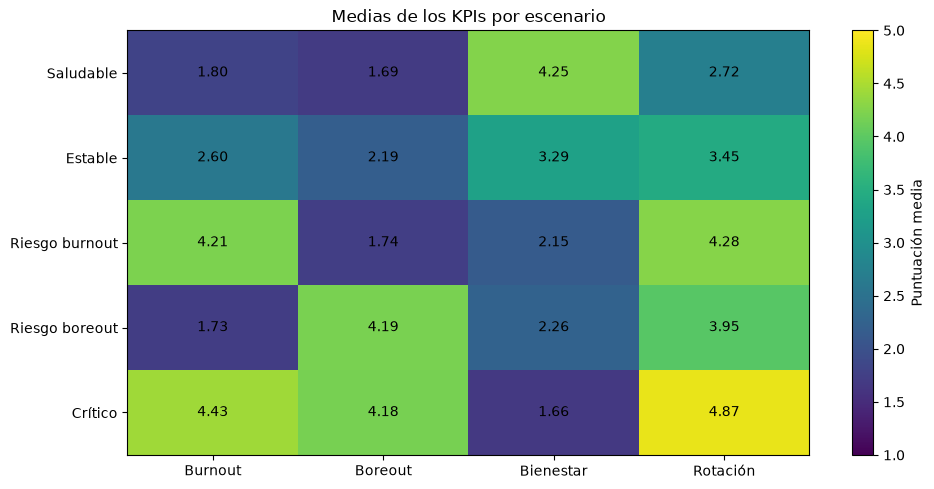

In [8]:
import matplotlib.pyplot as plt

columnas_kpi = [
    "kpi_burnout",
    "kpi_boreout",
    "kpi_bienestar",
    "kpi_rotacion"
]

medias_kpi = (
    df_benchmark
    .groupby("escenario")[columnas_kpi]
    .mean()
    .reindex([
        "saludable",
        "estable",
        "riesgo_burnout",
        "riesgo_boreout",
        "critico"
    ])
)

fig, ax = plt.subplots(figsize=(10, 5))

imagen = ax.imshow(
    medias_kpi.values,
    aspect="auto",
    vmin=1,
    vmax=5
)

ax.set_xticks(range(len(columnas_kpi)))
ax.set_xticklabels([
    "Burnout",
    "Boreout",
    "Bienestar",
    "Rotación"
])

ax.set_yticks(range(len(medias_kpi.index)))
ax.set_yticklabels([
    "Saludable",
    "Estable",
    "Riesgo burnout",
    "Riesgo boreout",
    "Crítico"
])

for fila in range(len(medias_kpi.index)):
    for columna in range(len(columnas_kpi)):
        valor = medias_kpi.iloc[fila, columna]

        ax.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Medias de los KPIs por escenario")

fig.colorbar(
    imagen,
    ax=ax,
    label="Puntuación media"
)

plt.tight_layout()
plt.show()

fig.savefig(
    "../../visualizaciones/02_heatmap_kpis.png",
    dpi=300,
    bbox_inches="tight"
)

In [9]:
import pandas as pd
import plotly.express as px
from pathlib import Path
import sys

# Ruta al código fuente del proyecto
sys.path.append("../src")

from estilos import COLORES_CULTURA, aplicar_estilo
# Crear un DataFrame con una fila por empresa
df_empresas = (
    df_benchmark[
        ["empresa_id", "escenario", "cultura"]
    ]
    .drop_duplicates(subset="empresa_id")
    .copy()
)

print(df_empresas.shape)
df_empresas.head()

# Orden lógico de los escenarios
orden_escenarios = [
    "saludable",
    "estable",
    "riesgo_boreout",
    "riesgo_burnout",
    "critico"
]

# Nombres legibles
nombres_escenarios = {
    "saludable": "Saludable",
    "estable": "Estable",
    "riesgo_boreout": "Riesgo de boreout",
    "riesgo_burnout": "Riesgo de burnout",
    "critico": "Crítico"
}

# Distribución porcentual de culturas
distribucion_cultura = (
    df_empresas
    .groupby(["escenario", "cultura"])
    .size()
    .reset_index(name="n_empresas")
)

# Total de empresas por escenario
distribucion_cultura["porcentaje"] = (
    distribucion_cultura["n_empresas"]
    / distribucion_cultura.groupby("escenario")["n_empresas"].transform("sum")
    * 100
)

# Aplicar orden y nombres legibles
distribucion_cultura["escenario"] = pd.Categorical(
    distribucion_cultura["escenario"],
    categories=orden_escenarios,
    ordered=True
)

distribucion_cultura = distribucion_cultura.sort_values("escenario")

distribucion_cultura["escenario_nombre"] = (
    distribucion_cultura["escenario"]
    .map(nombres_escenarios)
)

# Crear gráfico
fig = px.bar(
    distribucion_cultura,
    x="escenario_nombre",
    y="porcentaje",
    color="cultura",
    text="porcentaje",
    color_discrete_map=COLORES_CULTURA,
    category_orders={
        "escenario_nombre": [
            "Saludable",
            "Estable",
            "Riesgo de boreout",
            "Riesgo de burnout",
            "Crítico"
        ],
        "cultura": [
            "Adhocracia",
            "Clan",
            "Mercado",
            "Jerarquica"
        ]
    },
    labels={
        "escenario_nombre": "Escenario organizacional",
        "porcentaje": "Empresas (%)",
        "cultura": "Cultura"
    }
)

# Barras apiladas al 100 %
fig.update_layout(
    barmode="stack",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig.update_traces(
    texttemplate="%{text:.0f}%",
    textposition="inside"
)

fig.update_yaxes(
    range=[0, 100],
    ticksuffix="%"
)

fig = aplicar_estilo(
    fig,
    titulo="Distribución de culturas organizacionales por escenario",
    ancho=1050,
    alto=600
)

fig.show()

ruta_salida = Path("../../visualizaciones")
ruta_salida.mkdir(parents=True, exist_ok=True)

fig.write_image(
    ruta_salida / "02_distribucion_culturas_escenario.png",
    scale=2
)

(250, 3)


In [10]:
# Orden lógico de las categorías
orden_seniority = ["Junior", "Mid", "Senior", "Lead"]

# Calcular frecuencias y porcentajes
distribucion_seniority = (
    df_benchmark["seniority"]
    .value_counts()
    .reindex(orden_seniority)
    .rename_axis("seniority")
    .reset_index(name="n_empleados")
)

distribucion_seniority["porcentaje"] = (
    distribucion_seniority["n_empleados"]
    / distribucion_seniority["n_empleados"].sum()
    * 100
)

distribucion_seniority

fig_seniority = px.bar(
    distribucion_seniority,
    x="seniority",
    y="porcentaje",
    text="porcentaje",
    category_orders={
        "seniority": orden_seniority
    },
    labels={
        "seniority": "Nivel de seniority",
        "porcentaje": "Empleados (%)"
    }
)

fig_seniority.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    cliponaxis=False
)

fig_seniority.update_yaxes(
    range=[
        0,
        distribucion_seniority["porcentaje"].max() + 8
    ],
    ticksuffix="%"
)

fig_seniority = aplicar_estilo(
    fig_seniority,
    titulo="Distribución de empleados por nivel de seniority",
    ancho=900,
    alto=550
)

fig_seniority.show()

RUTA_VISUALIZACIONES.mkdir(parents=True, exist_ok=True)
fig_seniority.write_image(
    RUTA_VISUALIZACIONES / "03_distribucion_seniority.png",
    scale=2
)

In [11]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ============================================================
# DISTRIBUCIÓN DE KPIs POR ESCENARIO
# ============================================================

COLORES_ESCENARIOS = {
    "saludable": "#2E8B57",
    "estable": "#4C78A8",
    "riesgo_boreout": "#F2C14E",
    "riesgo_burnout": "#E67E22",
    "critico": "#C0392B",
}

nombres_escenarios = {
    "saludable": "Saludable",
    "estable": "Estable",
    "riesgo_boreout": "Riesgo boreout",
    "riesgo_burnout": "Riesgo burnout",
    "critico": "Crítico",
}

# Paleta adaptada a los nombres visibles
colores_nombres = {
    nombres_escenarios[escenario]: color
    for escenario, color in COLORES_ESCENARIOS.items()
}

orden = [
    "Saludable",
    "Estable",
    "Riesgo boreout",
    "Riesgo burnout",
    "Crítico",
]

df = df_benchmark.copy()

df["Escenario"] = (
    df["escenario"]
    .map(nombres_escenarios)
)

variables = {
    "Burnout": "kpi_burnout",
    "Boreout": "kpi_boreout",
    "Bienestar": "kpi_bienestar",
    "Rotación": "kpi_rotacion",
}

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=list(variables.keys()),
)

posiciones = [
    (1, 1),
    (1, 2),
    (2, 1),
    (2, 2),
]

for (titulo, columna), (fila, col) in zip(
    variables.items(),
    posiciones,
):
    for escenario in orden:

        datos = df.loc[
            df["Escenario"] == escenario,
            columna,
        ]

        fig.add_trace(
            go.Box(
                y=datos,
                name=escenario,
                boxmean=True,
                marker_color=colores_nombres[escenario],
                showlegend=(fila == 1 and col == 1),
                legendgroup=escenario,
            ),
            row=fila,
            col=col,
        )

fig.update_yaxes(
    range=[1, 5],
    title_text="Puntuación",
)

fig.update_layout(
    title="Distribución de los principales KPIs por escenario",
    template="simple_white",
    height=750,
    width=1100,
    legend=dict(
    orientation="h",
    yanchor="top",
    y=-0.08,
    xanchor="center",
    x=0.5,
    ),
)

fig.show()

ruta_salida = (
    RUTA_VISUALIZACIONES
    / "04_boxplots_kpis.png"
)

fig.write_image(
    ruta_salida,
    scale=2,
)



In [12]:
import pandas as pd
import plotly.express as px

from costes_rotacion import calcular_coste_rotacion_empleado

# Copia del benchmark
df_costes = df_benchmark.copy()

# Calcular el coste esperado de rotación de cada empleado
df_costes["coste_rotacion_individual"] = df_costes.apply(
    calcular_coste_rotacion_empleado,
    axis=1
)

# Nombres de escenarios
nombres_escenarios = {
    "saludable": "Saludable",
    "estable": "Estable",
    "riesgo_boreout": "Riesgo de boreout",
    "riesgo_burnout": "Riesgo de burnout",
    "critico": "Crítico"
}

# Adaptar el nombre de la columna de escenario
columna_escenario = (
    "escenario_nombre"
    if "escenario_nombre" in df_costes.columns
    else "escenario"
)

df_costes["escenario_grafico"] = (
    df_costes[columna_escenario]
    .replace(nombres_escenarios)
)

orden_escenarios = [
    "Saludable",
    "Estable",
    "Riesgo de boreout",
    "Riesgo de burnout",
    "Crítico"
]

# Resumen por escenario
resumen_costes = (
    df_costes
    .groupby("escenario_grafico", as_index=False)
    .agg(
        coste_medio_rotacion=("coste_rotacion_individual", "mean"),
        coste_total_rotacion=("coste_rotacion_individual", "sum"),
        n_empleados=("empleado_id", "count")
    )
)

resumen_costes["escenario_grafico"] = pd.Categorical(
    resumen_costes["escenario_grafico"],
    categories=orden_escenarios,
    ordered=True
)

resumen_costes = resumen_costes.sort_values("escenario_grafico")

# Gráfico
fig_costes = px.bar(
    resumen_costes,
    x="escenario_grafico",
    y="coste_medio_rotacion",
    text_auto=".0f",
    category_orders={
        "escenario_grafico": orden_escenarios
    },
    labels={
        "escenario_grafico": "Escenario organizacional",
        "coste_medio_rotacion": "Coste esperado por empleado (€)"
    },
    title="Coste esperado de rotación por empleado y escenario"
)

fig_costes.update_traces(
    texttemplate="%{y:,.0f} €",
    textposition="outside",
    cliponaxis=False
)

fig_costes.update_layout(
    template="simple_white",
    width=1050,
    height=600,
    showlegend=False,
    xaxis_title="",
    yaxis_title="Coste esperado por empleado (€)",
    margin=dict(t=90, r=40, b=80, l=90)
)

fig_costes.update_yaxes(
    tickprefix="€",
    separatethousands=True
)

fig_costes.show()

# Guardar en la carpeta visualizaciones de la raíz
fig_costes.write_image(
    RUTA_VISUALIZACIONES / "05_coste_rotacion_escenario.png",
    scale=2
)



In [14]:
import pandas as pd
import plotly.express as px


# ============================================================
# DISTRIBUCIÓN DE KPIs POR ESCENARIO
# ============================================================

kpi_cols = [
    "kpi_burnout",
    "kpi_boreout",
    "kpi_bienestar",
    "kpi_rotacion",
    "kpi_contexto",
]

nombres_kpi = {
    "kpi_burnout": "Burnout",
    "kpi_boreout": "Boreout",
    "kpi_bienestar": "Bienestar",
    "kpi_rotacion": "Intención de cambio",
    "kpi_contexto": "Contexto",
}

nombres_escenarios = {
    "saludable": "Saludable",
    "estable": "Estable",
    "riesgo_boreout": "Riesgo de boreout",
    "riesgo_burnout": "Riesgo de burnout",
    "critico": "Crítico",
}

orden_escenarios = [
    "Saludable",
    "Estable",
    "Riesgo de boreout",
    "Riesgo de burnout",
    "Crítico",
]

colores_escenarios_visibles = {
    "Saludable": "#2E8B57",
    "Estable": "#4C78A8",
    "Riesgo de boreout": "#F2C14E",
    "Riesgo de burnout": "#E67E22",
    "Crítico": "#C0392B",
}


# Preparar datos en formato largo
df_kpis_largo = (
    df_benchmark[
        ["escenario", *kpi_cols]
    ]
    .melt(
        id_vars="escenario",
        var_name="kpi",
        value_name="valor",
    )
)

df_kpis_largo["Escenario"] = (
    df_kpis_largo["escenario"]
    .replace(nombres_escenarios)
)

df_kpis_largo["KPI"] = (
    df_kpis_largo["kpi"]
    .replace(nombres_kpi)
)


# Convertir el escenario en variable categórica ordenada
df_kpis_largo["Escenario"] = pd.Categorical(
    df_kpis_largo["Escenario"],
    categories=orden_escenarios,
    ordered=True,
)

df_kpis_largo = df_kpis_largo.sort_values(
    "Escenario"
)


# Gráfico
fig_kpis = px.box(
    df_kpis_largo,
    x="Escenario",
    y="valor",
    color="Escenario",
    facet_col="KPI",
    color_discrete_map=colores_escenarios_visibles,
    facet_col_wrap=3,
    category_orders={
        "Escenario": orden_escenarios,
        "KPI": [
            "Burnout",
            "Boreout",
            "Bienestar",
            "Intención de cambio",
            "Contexto",
        ],
    },
    points=False,
    labels={
        "valor": "Puntuación",
        "Escenario": "",
    },
    title="Distribución de KPIs por escenario organizacional",
)


# Limpiar títulos de cada panel
fig_kpis.for_each_annotation(
    lambda anotacion: anotacion.update(
        text=anotacion.text.split("=")[-1]
    )
)


# Formato
fig_kpis.update_yaxes(
    range=[1, 5],
    dtick=1,
)

fig_kpis.update_layout(
    template="simple_white",
    width=1200,
    height=850,
    showlegend=False,
    margin=dict(
        t=100,
        r=40,
        b=90,
        l=80,
    ),
)

fig_kpis.show()


# Guardar en la carpeta visualizaciones de la raíz
fig_kpis.write_image(
    RUTA_VISUALIZACIONES
    / "06_distribucion_kpis_escenario.png",
    scale=2,
)



In [15]:
# ============================================================
# MATRIZ DE CORRELACIONES ENTRE KPIs
# ============================================================

import plotly.express as px


kpi_cols = [
    "kpi_burnout",
    "kpi_boreout",
    "kpi_bienestar",
    "kpi_rotacion",
    "kpi_contexto",
]

nombres_kpi = {
    "kpi_burnout": "Burnout",
    "kpi_boreout": "Boreout",
    "kpi_bienestar": "Bienestar",
    "kpi_rotacion": "Intención de cambio",
    "kpi_contexto": "Contexto",
}


# Calcular matriz de correlaciones
matriz_correlaciones = (
    df_benchmark[kpi_cols]
    .corr()
)


# Renombrar filas y columnas para la visualización
matriz_correlaciones_grafico = (
    matriz_correlaciones
    .rename(
        index=nombres_kpi,
        columns=nombres_kpi,
    )
)


# Gráfico
fig_correlaciones = px.imshow(
    matriz_correlaciones_grafico,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    labels={
        "color": "Correlación",
    },
    title="Matriz de correlaciones entre los principales KPIs",
)


# Formato
fig_correlaciones.update_traces(
    textfont_size=16,
)

fig_correlaciones.update_layout(
    template="simple_white",
    width=900,
    height=700,
    margin=dict(
        t=100,
        r=100,
        b=110,
        l=130,
    ),
)

fig_correlaciones.update_xaxes(
    side="bottom",
    tickangle=-25,
    title="",
)

fig_correlaciones.update_yaxes(
    title="",
)


# Mostrar gráfico
fig_correlaciones.show()


# Guardar en la carpeta visualizaciones de la raíz
fig_correlaciones.write_image(
    RUTA_VISUALIZACIONES
    / "07_correlaciones_kpis.png",
    scale=2,
)



In [16]:
# ============================================================
# PERFIL MEDIO DE LOS ESCENARIOS ORGANIZACIONALES
# ============================================================

kpis = [
    "kpi_contexto",
    "kpi_bienestar",
    "kpi_burnout",
    "kpi_boreout",
    "kpi_rotacion",
]

ETIQUETAS_ES = {
    "saludable": "Saludable",
    "estable": "Estable",
    "riesgo_boreout": "Riesgo de boreout",
    "riesgo_burnout": "Riesgo de burnout",
    "critico": "Crítico",
}

COLORES_ES = {
    "Saludable": "#2E8B57",
    "Estable": "#4C78A8",
    "Riesgo de boreout": "#F2C14E",
    "Riesgo de burnout": "#E67E22",
    "Crítico": "#C0392B",
}   

medias = (
    df_benchmark
    .groupby("escenario")[kpis]
    .mean()
    .rename(index=ETIQUETAS_ES)
)

fig = go.Figure()

for escenario in medias.index:

    fig.add_trace(
        go.Scatter(
            x=[
                "Contexto",
                "Bienestar",
                "Burnout",
                "Boreout",
                "Rotación",
            ],
            y=medias.loc[escenario],
            mode="lines+markers",
            name=escenario,
            line=dict(width=3, color=COLORES_ES[escenario]),
            marker=dict(size=8, color=COLORES_ES[escenario]),
        )
    )

aplicar_estilo(
    fig,
    titulo="Perfil medio de los escenarios organizacionales"
)

fig.update_yaxes(range=[1, 5])

fig.show()

fig.write_image(
    RUTA_VISUALIZACIONES /
    "09_perfil_escenarios.png",
    scale=2
)



In [17]:
# ============================================================
# PREPARACIÓN Y AJUSTE DEL PCA
# ============================================================

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Seleccionar las preguntas del cuestionario
preguntas_cols = [
    columna
    for columna in df_benchmark.columns
    if columna.startswith("q")
    and columna[1:].isdigit()
]

# Ordenar correctamente: q1, q2, ..., q67
preguntas_cols = sorted(
    preguntas_cols,
    key=lambda columna: int(columna.replace("q", ""))
)

# Matriz de respuestas
df_preguntas_pca = (
    df_benchmark[preguntas_cols]
    .dropna()
)

# Estandarización
escalador = StandardScaler()

X_estandarizado = escalador.fit_transform(
    df_preguntas_pca
)

# Ajuste del PCA
pca = PCA()

coordenadas_pca = pca.fit_transform(
    X_estandarizado
)

# Varianza explicada
varianza = pca.explained_variance_ratio_

varianza_acumulada = np.cumsum(
    varianza
)

print(
    f"PCA calculado sobre "
    f"{len(preguntas_cols)} ítems y "
    f"{len(df_preguntas_pca):,} empleados."
)

print(
    f"Varianza explicada por PC1: "
    f"{varianza[0] * 100:.2f} %"
)

print(
    f"Varianza explicada por PC2: "
    f"{varianza[1] * 100:.2f} %"
)

PCA calculado sobre 67 ítems y 12,500 empleados.
Varianza explicada por PC1: 55.88 %
Varianza explicada por PC2: 16.46 %


In [18]:
# ============================================================
# VARIANZA EXPLICADA POR EL PCA
# ============================================================

fig = go.Figure()

# Varianza individual
fig.add_trace(
    go.Bar(
        x=[f"PC{i+1}" for i in range(10)],
        y=varianza[:10] * 100,
        name="Varianza individual",
        marker_color="#4C78A8",
        text=[f"{v * 100:.1f}%" for v in varianza[:10]],
        textposition="outside",
    )
)

# Varianza acumulada
fig.add_trace(
    go.Scatter(
        x=[f"PC{i+1}" for i in range(10)],
        y=varianza_acumulada[:10] * 100,
        name="Varianza acumulada",
        mode="lines+markers",
        line=dict(
            color="#E45756",
            width=3,
        ),
        marker=dict(size=8),
        yaxis="y2",
    )
)

# Umbral de referencia del 80 %
fig.add_hline(
    y=80,
    line_dash="dash",
    line_color="green",
    annotation_text="80 %",
    annotation_position="top right",
    yref="y2",
)

fig.update_layout(
    title="Varianza explicada por los componentes principales",

    xaxis_title="Componente principal",

    yaxis=dict(
        title="Varianza individual (%)",
        range=[0, 60],
    ),

    yaxis2=dict(
        title="Varianza acumulada (%)",
        overlaying="y",
        side="right",
        range=[0, 100],
    ),

    height=550,

    legend=dict(
        orientation="h",
        y=1.08,
        x=0.5,
        xanchor="center",
    ),

    margin=dict(
        t=100,
        r=90,
        b=70,
        l=80,
    ),
)

aplicar_estilo(fig)

fig.show()

fig.write_image(
    RUTA_VISUALIZACIONES
    / "10_varianza_explicada_pca.png",
    scale=2,
)



In [19]:
# ============================================================
# POSICIONAMIENTO DE LEGACYTECH FRENTE AL BENCHMARK
# ============================================================

import pandas as pd
import plotly.graph_objects as go


ESCENARIOS = [
    "saludable",
    "estable",
    "riesgo_burnout",
    "riesgo_boreout",
    "critico",
]

COLORES_ESCENARIOS = {
    "saludable": "#2E8B57",
    "estable": "#4C78A8",
    "riesgo_boreout": "#F2C14E",
    "riesgo_burnout": "#E67E22",
    "critico": "#C0392B",
}

NOMBRES_ESCENARIOS = {
    "saludable": "Saludable",
    "estable": "Estable",
    "riesgo_boreout": "Riesgo de boreout",
    "riesgo_burnout": "Riesgo de burnout",
    "critico": "Crítico",
}


# ============================================================
# CARGA DE DATOS PARA LEGACYTECH
# ============================================================

ruta_legacy = (
    RUTA_DATASETS
    / "legacy_tech_ligero.csv"
)

if not ruta_legacy.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset de LegacyTech: {ruta_legacy}"
    )

df_legacy = pd.read_csv(ruta_legacy)


ESCENARIOS = [
    "saludable",
    "estable",
    "riesgo_burnout",
    "riesgo_boreout",
    "critico",
]

dfs_benchmark = []

for escenario in ESCENARIOS:

    ruta_escenario = (
        RUTA_DATASETS
        / escenario
        / "empleados.csv"
    )

    if not ruta_escenario.exists():
        raise FileNotFoundError(
            f"No se encontró el escenario: {ruta_escenario}"
        )

    df_escenario = pd.read_csv(ruta_escenario)
    df_escenario["escenario"] = escenario

    dfs_benchmark.append(df_escenario)

df_benchmark = pd.concat(
    dfs_benchmark,
    ignore_index=True,
)

print(
    f"LegacyTech cargado: {len(df_legacy)} empleados"
)

print(
    f"Benchmark cargado: {len(df_benchmark)} empleados"
)


# ============================================================
# CARGA DEL BENCHMARK
# ============================================================

dfs_benchmark = []

for escenario in ESCENARIOS:

    ruta_escenario = (
        RUTA_DATASETS
        / escenario
        / "empleados.csv"
    )

    df_escenario = pd.read_csv(ruta_escenario)
    df_escenario["escenario"] = escenario

    dfs_benchmark.append(df_escenario)


df_benchmark = pd.concat(
    dfs_benchmark,
    ignore_index=True,
)


# ============================================================
# CÁLCULOS
# ============================================================

legacy_burnout = (
    df_legacy["kpi_burnout"]
    .mean()
)

legacy_boreout = (
    df_legacy["kpi_boreout"]
    .mean()
)

centroides_benchmark = (
    df_benchmark
    .groupby("escenario")[
        ["kpi_burnout", "kpi_boreout"]
    ]
    .mean()
    .reindex(ESCENARIOS)
)


# ============================================================
# GRÁFICO
# ============================================================

fig = go.Figure()


# Centroides del benchmark
for escenario in ESCENARIOS:

    fig.add_trace(
        go.Scatter(
            x=[
                centroides_benchmark.loc[
                    escenario,
                    "kpi_burnout",
                ]
            ],
            y=[
                centroides_benchmark.loc[
                    escenario,
                    "kpi_boreout",
                ]
            ],
            mode="markers",
            marker=dict(
                size=20,
                color=COLORES_ESCENARIOS[escenario],
                symbol="diamond",
                line=dict(
                    width=2,
                    color="#263645",
                ),
            ),
            name=NOMBRES_ESCENARIOS[escenario],
        )
    )


# Posición de LegacyTech
fig.add_trace(
    go.Scatter(
        x=[legacy_burnout],
        y=[legacy_boreout],
        mode="markers+text",
        marker=dict(
            size=25,
            color="black",
            symbol="star",
            line=dict(
                width=3,
                color="#C0392B",
            ),
        ),
        text=["LegacyTech"],
        textposition="top center",
        textfont=dict(
            size=12,
            family="Arial Black",
        ),
        name="LegacyTech",
    )
)


# Límites de riesgo
fig.add_vline(
    x=3.5,
    line_width=2,
    line_dash="dash",
    line_color="#7F8C8D",
    opacity=0.8,
    annotation_text="Límite burnout = 3.5",
    annotation_position="top right",
)

fig.add_hline(
    y=3.5,
    line_width=2,
    line_dash="dash",
    line_color="#7F8C8D",
    opacity=0.8,
    annotation_text="Límite boreout = 3.5",
    annotation_position="top left",
)


# Etiquetas de cuadrantes
fig.add_annotation(
    x=0.02,
    y=0.02,
    xref="x domain",
    yref="y domain",
    text="Saludable",
    showarrow=False,
    xanchor="left",
    yanchor="bottom",
    font=dict(
        size=11,
        color="#2E8B57",
        family="Arial Black",
    ),
)

fig.add_annotation(
    x=0.98,
    y=0.02,
    xref="x domain",
    yref="y domain",
    text="Riesgo Burnout",
    showarrow=False,
    xanchor="right",
    yanchor="bottom",
    font=dict(
        size=11,
        color="#E67E22",
        family="Arial Black",
    ),
)

fig.add_annotation(
    x=0.02,
    y=0.98,
    xref="x domain",
    yref="y domain",
    text="Riesgo Boreout",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    font=dict(
        size=11,
        color="#F2C14E",
        family="Arial Black",
    ),
)

fig.add_annotation(
    x=0.98,
    y=0.98,
    xref="x domain",
    yref="y domain",
    text="Crítico",
    showarrow=False,
    xanchor="right",
    yanchor="top",
    font=dict(
        size=11,
        color="#C0392B",
        family="Arial Black",
    ),
)


fig.update_layout(
    height=700,
    width=900,
    xaxis=dict(
        title="Burnout",
        range=[1, 5.2],
    ),
    yaxis=dict(
        title="Boreout",
        range=[1, 5.2],
    ),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.15,
        xanchor="center",
        x=0.5,
    ),
)


aplicar_estilo(
    fig,
    titulo="Posicionamiento de LegacyTech frente al benchmark",
    ancho=1000,
    alto=750,
)


fig.show()


ruta_salida = (
    RUTA_VISUALIZACIONES
    / "12_posicionamiento_legacytech_benchmark.png"
)

fig.write_image(
    ruta_salida,
    scale=2,
)



LegacyTech cargado: 180 empleados
Benchmark cargado: 12500 empleados


In [24]:
# =====================================================
# HEATMAPS DE KPIs POR DEPARTAMENTO Y SENIORITY
# LEGACYTECH
# =====================================================

import pandas as pd
import plotly.express as px

from estilos import aplicar_estilo, COLORES_EBLET


# -----------------------------------------------------
# 1. Configuración
# -----------------------------------------------------

ORDEN_SENIORITY = [
    "Junior",
    "Mid",
    "Senior",
    "Manager"
]

KPIS_HEATMAP = {
    "kpi_burnout": {
        "nombre": "Burnout",
        "escala": [
            [0.00, "#F8EEEE"],
            [0.50, "#D89A9A"],
            [1.00, COLORES_EBLET["Burnout"]],
        ],
    },
    "kpi_boreout": {
        "nombre": "Boreout",
        "escala": [
            [0.00, "#EEF3F7"],
            [0.50, "#91AFC5"],
            [1.00, COLORES_EBLET["Boreout"]],
        ],
    },
    "kpi_bienestar": {
        "nombre": "Bienestar",
        "escala": [
            [0.00, "#EFF5F2"],
            [0.50, "#9ABAAA"],
            [1.00, COLORES_EBLET["Bienestar"]],
        ],
    },
}


# -----------------------------------------------------
# 2. Calcular medias
# -----------------------------------------------------

df_medias = (
    df_legacy
    .groupby(
        ["departamento", "seniority"],
        observed=True
    )[
        ["kpi_burnout", "kpi_boreout", "kpi_bienestar"]
    ]
    .mean()
    .reset_index()
)


# -----------------------------------------------------
# 3. Función para crear cada heatmap
# -----------------------------------------------------

def crear_heatmap_kpi(
    df,
    columna_kpi,
    nombre_kpi,
    escala_color,
    orden_seniority=None
):
    matriz = df.pivot(
        index="departamento",
        columns="seniority",
        values=columna_kpi
    )

    # Mantener un orden lógico de seniority
    if orden_seniority is not None:
        columnas_disponibles = [
            nivel
            for nivel in orden_seniority
            if nivel in matriz.columns
        ]

        columnas_restantes = [
            nivel
            for nivel in matriz.columns
            if nivel not in columnas_disponibles
        ]

        matriz = matriz.reindex(
            columns=columnas_disponibles + columnas_restantes
        )

    fig = px.imshow(
        matriz,
        color_continuous_scale=escala_color,
        zmin=1,
        zmax=5,
        text_auto=".2f",
        aspect="auto",
        labels={
            "x": "Seniority",
            "y": "Departamento",
            "color": nombre_kpi
        }
    )

    fig.update_traces(
        hovertemplate=(
            "<b>Departamento:</b> %{y}<br>"
            "<b>Seniority:</b> %{x}<br>"
            f"<b>{nombre_kpi} medio:</b> %{{z:.2f}}"
            "<extra></extra>"
        ),
        textfont=dict(size=13)
    )

    fig.update_coloraxes(
        colorbar=dict(
            title=nombre_kpi,
            tickvals=[1, 2, 3, 4, 5],
            thickness=14
        )
    )

    aplicar_estilo(
        fig,
        titulo=f"{nombre_kpi} medio por departamento y seniority",
        ancho=900,
        alto=520
    )

    fig.update_layout(
        margin=dict(
            l=120,
            r=80,
            t=100,
            b=80
        )
    )

    fig.update_xaxes(
        side="bottom",
        title_standoff=15
    )

    fig.update_yaxes(
        autorange="reversed",
        showgrid=False
    )

    return fig


# -----------------------------------------------------
# 4. Crear visualizaciones
# -----------------------------------------------------

fig_burnout = crear_heatmap_kpi(
    df=df_medias,
    columna_kpi="kpi_burnout",
    nombre_kpi="Burnout",
    escala_color=KPIS_HEATMAP["kpi_burnout"]["escala"],
    orden_seniority=ORDEN_SENIORITY
)

fig_boreout = crear_heatmap_kpi(
    df=df_medias,
    columna_kpi="kpi_boreout",
    nombre_kpi="Boreout",
    escala_color=KPIS_HEATMAP["kpi_boreout"]["escala"],
    orden_seniority=ORDEN_SENIORITY
)

fig_bienestar = crear_heatmap_kpi(
    df=df_medias,
    columna_kpi="kpi_bienestar",
    nombre_kpi="Bienestar",
    escala_color=KPIS_HEATMAP["kpi_bienestar"]["escala"],
    orden_seniority=ORDEN_SENIORITY
)


fig_burnout.show()
fig_boreout.show()
fig_bienestar.show()


from pathlib import Path

RUTA_VISUALIZACIONES = Path("../../visualizaciones").resolve()
RUTA_VISUALIZACIONES.mkdir(parents=True, exist_ok=True)

rutas_guardadas = {
    "burnout": RUTA_VISUALIZACIONES / "legacytech_burnout_departamento_seniority.png",
    "boreout": RUTA_VISUALIZACIONES / "legacytech_boreout_departamento_seniority.png",
    "bienestar": RUTA_VISUALIZACIONES / "legacytech_bienestar_departamento_seniority.png",
}

fig_burnout.write_image(rutas_guardadas["burnout"], scale=2)
fig_boreout.write_image(rutas_guardadas["boreout"], scale=2)
fig_bienestar.write_image(rutas_guardadas["bienestar"], scale=2)


In [25]:
# =====================================================
# BRECHA ENTRE CULTURA DECLARADA Y CULTURA PERCIBIDA
# LEGACYTECH
# =====================================================

import pandas as pd
import plotly.graph_objects as go

from cultura_cvf import clasificar_cultura_empresa
from estilos import aplicar_estilo


# -----------------------------------------------------
# 1. Cultura declarada por LegacyTech
# -----------------------------------------------------
# Valores de ejemplo en escala 1-5.
# Deben sustituirse por los definidos para el caso LegacyTech.

cultura_declarada = {
    "Adhocracia": 4.20,
    "Clan": 3.80,
    "Mercado": 3.00,
    "Jerarquica": 2.50
}


# -----------------------------------------------------
# 2. Cultura percibida por los empleados
# -----------------------------------------------------

resultado_cultura = clasificar_cultura_empresa(df_legacy)

cultura_percibida = {
    cultura: round(valor, 2)
    for cultura, valor in resultado_cultura["scores"].items()
}


# -----------------------------------------------------
# 3. Calcular la brecha cultural
# -----------------------------------------------------

df_brecha_cultural = pd.DataFrame({
    "cultura": cultura_declarada.keys(),
    "declarada": cultura_declarada.values(),
    "percibida": [
        cultura_percibida[cultura]
        for cultura in cultura_declarada.keys()
    ]
})

df_brecha_cultural["brecha"] = (
    df_brecha_cultural["percibida"]
    - df_brecha_cultural["declarada"]
).round(2)

df_brecha_cultural["brecha_absoluta"] = (
    df_brecha_cultural["brecha"].abs()
)

df_brecha_cultural

,cultura,declarada,percibida,brecha,brecha_absoluta
0,Adhocracia,4.2,1.99,-2.21,2.21
1,Clan,3.8,2.00,-1.80,1.80
2,Mercado,3.0,2.02,-0.98,0.98
3,Jerarquica,2.5,3.98,1.48,1.48


In [26]:
# -----------------------------------------------------
# 4. Crear gráfico radar
# -----------------------------------------------------

categorias = df_brecha_cultural["cultura"].tolist()

valores_declarados = df_brecha_cultural["declarada"].tolist()
valores_percibidos = df_brecha_cultural["percibida"].tolist()

# Cerrar el radar repitiendo el primer valor
categorias_cerradas = categorias + [categorias[0]]
declarados_cerrados = valores_declarados + [valores_declarados[0]]
percibidos_cerrados = valores_percibidos + [valores_percibidos[0]]

fig_cultura = go.Figure()

fig_cultura.add_trace(
    go.Scatterpolar(
        r=declarados_cerrados,
        theta=categorias_cerradas,
        fill="toself",
        name="Cultura declarada",
        opacity=0.45,
        hovertemplate=(
            "<b>%{theta}</b><br>"
            "Cultura declarada: %{r:.2f}"
            "<extra></extra>"
        )
    )
)

fig_cultura.add_trace(
    go.Scatterpolar(
        r=percibidos_cerrados,
        theta=categorias_cerradas,
        fill="toself",
        name="Cultura percibida",
        opacity=0.45,
        hovertemplate=(
            "<b>%{theta}</b><br>"
            "Cultura percibida: %{r:.2f}"
            "<extra></extra>"
        )
    )
)

fig_cultura.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[1, 5],
            tickvals=[1, 2, 3, 4, 5]
        )
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.18,
        xanchor="center",
        x=0.5
    )
)

aplicar_estilo(
    fig_cultura,
    titulo="Cultura declarada frente a cultura percibida",
    ancho=850,
    alto=650
)

ruta_salida = (
    Path("../../visualizaciones")
    / "legacytech_cultura_declarada_vs_percibida.png"
).resolve()
ruta_salida.parent.mkdir(parents=True, exist_ok=True)

fig_cultura.show()

fig_cultura.write_image(
    str(ruta_salida),
    scale=2
)




In [27]:
# =====================================================
# INDICADOR DE ROTACIÓN ANUAL ESTIMADA
# LEGACYTECH
# =====================================================

import plotly.graph_objects as go

from costes_rotacion import (
    kpi_a_tasa_rotacion,
    tasa_rotacion_a_categoria
)
from estilos import aplicar_estilo, COLORES_EBLET


def crear_gauge_rotacion(
    df,
    nombre_empresa="LegacyTech"
):
    """
    Crea un indicador de la tasa anual estimada de rotación.

    La tasa se obtiene transformando el KPI medio de intención
    de rotación mediante la función definida en costes_rotacion.py.
    """

    # KPI medio de intención de rotación
    kpi_rotacion_medio = df["kpi_rotacion"].mean()

    # Conversión a tasa anual estimada
    tasa_rotacion = kpi_a_tasa_rotacion(kpi_rotacion_medio)
    porcentaje_rotacion = tasa_rotacion * 100

    # Categoría de riesgo
    categoria = tasa_rotacion_a_categoria(tasa_rotacion)

    # Número estimado de bajas
    n_empleados = len(df)
    n_bajas_estimadas = round(n_empleados * tasa_rotacion)

    fig = go.Figure(
        go.Indicator(
            mode="gauge+number",
            value=porcentaje_rotacion,

            number={
                "suffix": " %",
                "font": {
                    "size": 48,
                    "color": COLORES_EBLET["Rotacion"]
                }
            },

            title={
                "text": (
                    f"<b>{categoria}</b><br>"
                    f"<span style='font-size:14px'>"
                    f"{n_bajas_estimadas} bajas estimadas "
                    f"sobre {n_empleados} empleados"
                    f"</span>"
                )
            },

            gauge={
                "axis": {
                    "range": [0, 50],
                    "tickvals": [0, 10, 20, 35, 50],
                    "ticksuffix": " %"
                },

                "bar": {
                    "color": COLORES_EBLET["Rotacion"],
                    "thickness": 0.28
                },

                "bgcolor": "white",
                "borderwidth": 0,

                "steps": [
                    {
                        "range": [0, 10],
                        "color": "#EAF2ED"
                    },
                    {
                        "range": [10, 20],
                        "color": "#F4EEDC"
                    },
                    {
                        "range": [20, 35],
                        "color": "#F2DFD2"
                    },
                    {
                        "range": [35, 50],
                        "color": "#EBD4D4"
                    }
                ],

                # Umbral que marca el inicio de la rotación alta
                "threshold": {
                    "line": {
                        "color": "#7A2E2E",
                        "width": 4
                    },
                    "thickness": 0.75,
                    "value": 20
                }
            }
        )
    )

    aplicar_estilo(
        fig,
        titulo=f"Rotación anual estimada en {nombre_empresa}",
        ancho=850,
        alto=500
    )

    fig.update_layout(
        margin=dict(
            l=80,
            r=80,
            t=110,
            b=50
        )
    )

    return fig

ruta_salida = (
    Path("../../visualizaciones")
    / "legacytech_coste_rotacion_departamento.png"
).resolve()
ruta_salida.parent.mkdir(parents=True, exist_ok=True)

fig_rotacion = crear_gauge_rotacion(
    df=df_legacy,
    nombre_empresa="LegacyTech"
)

fig_rotacion.show()

fig_rotacion.write_image(
    str(ruta_salida),
    scale=2
)



In [28]:
# 5. Salarios
df_legacy["salario_anual"] = (
    np.random.normal(35000, 10000, 180)
    .clip(20000, 60000)
    .round(0)
)
df_legacy["salario"] = df_legacy["salario_anual"]


In [29]:
print(df_legacy[["empleado_id", "salario_anual", "salario"]].head())
print("Salarios ausentes:", df_legacy["salario"].isna().sum())

   empleado_id  salario_anual  salario
0            1        35466.0  35466.0
1            2        50603.0  50603.0
2            3        34382.0  34382.0
3            4        47183.0  47183.0
4            5        42456.0  42456.0
Salarios ausentes: 0


In [30]:
import plotly.graph_objects as go

from costes_rotacion import calcular_coste_rotacion_empleado
from estilos import aplicar_estilo, COLORES_EBLET


def crear_coste_rotacion_departamento(df):
    """
    Calcula y representa el coste anual esperado de rotación
    por departamento.
    """

    columnas_necesarias = [
        "empleado_id",
        "departamento",
        "seniority",
        "kpi_rotacion"
    ]

    columnas_faltantes = [
        columna
        for columna in columnas_necesarias
        if columna not in df.columns
    ]

    if columnas_faltantes:
        raise ValueError(
            "No se puede calcular el coste de rotación. "
            f"Faltan las columnas: {columnas_faltantes}"
        )

    if (
        "salario" not in df.columns
        and "salario_anual" not in df.columns
    ):
        raise ValueError(
            "No se encuentra una columna salarial. "
            "Se esperaba 'salario' o 'salario_anual'."
        )

    df_calculo = df.copy()

    # LegacyTech utiliza salario_anual, mientras que la función
    # de costes espera una columna llamada salario.
    if "salario" not in df_calculo.columns:
        df_calculo["salario"] = df_calculo["salario_anual"]

    # Coste esperado individual
    df_calculo["coste_rotacion_individual"] = df_calculo.apply(
        calcular_coste_rotacion_empleado,
        axis=1
    )

    # Resumen por departamento
    df_costes = (
        df_calculo
        .groupby("departamento", observed=True)
        .agg(
            coste_anual_rotacion=(
                "coste_rotacion_individual",
                "sum"
            ),
            n_empleados=(
                "empleado_id",
                "count"
            ),
            kpi_rotacion_medio=(
                "kpi_rotacion",
                "mean"
            ),
            salario_medio=(
                "salario",
                "mean"
            )
        )
        .reset_index()
        .sort_values(
            "coste_anual_rotacion",
            ascending=True
        )
    )

    departamento_mayor_coste = df_costes.loc[
        df_costes["coste_anual_rotacion"].idxmax(),
        "departamento"
    ]

    color_rotacion = COLORES_EBLET.get(
        "Rotacion",
        "#B85450"
    )

    colores = [
        color_rotacion
        if departamento == departamento_mayor_coste
        else "#D8D8D8"
        for departamento in df_costes["departamento"]
    ]

    fig = go.Figure(
        go.Bar(
            x=df_costes["coste_anual_rotacion"],
            y=df_costes["departamento"],
            orientation="h",

            marker_color=colores,

            text=[
                f"{coste:,.0f} €".replace(",", ".")
                for coste in df_costes["coste_anual_rotacion"]
            ],
            textposition="outside",
            cliponaxis=False,

            customdata=df_costes[
                [
                    "n_empleados",
                    "kpi_rotacion_medio",
                    "salario_medio"
                ]
            ].to_numpy(),

            hovertemplate=(
                "<b>%{y}</b><br>"
                "Coste anual estimado: %{x:,.0f} €<br>"
                "Empleados: %{customdata[0]:.0f}<br>"
                "KPI de rotación medio: %{customdata[1]:.2f}<br>"
                "Salario medio: %{customdata[2]:,.0f} €"
                "<extra></extra>"
            )
        )
    )

    fig.update_xaxes(
        title="Coste anual estimado (€)",
        tickformat=",.0f",
        separatethousands=True,
        showgrid=True,
        gridcolor="#E5E5E5",
        zeroline=False
    )

    fig.update_yaxes(
        title=None,
        showgrid=False
    )

    aplicar_estilo(
        fig,
        titulo="Coste anual estimado de la rotación por departamento",
        ancho=950,
        alto=550
    )

    fig.update_layout(
        showlegend=False,
        bargap=0.30,
        margin={
            "l": 140,
            "r": 170,
            "t": 100,
            "b": 70
        }
    )

    return fig, df_costes

ruta_salida = (
    Path("../../visualizaciones")
    / "legacytech_coste_rotacion_departamento.png"
).resolve()

ruta_salida.parent.mkdir(parents=True, exist_ok=True)

fig_coste_departamento, resumen_costes_departamento = (
    crear_coste_rotacion_departamento(df_legacy)
)

fig_coste_departamento.write_image(
    str(ruta_salida),
    scale=2
)

fig_coste_departamento.show()




In [31]:
from costes_rotacion import calcular_roi_intervencion

# Coste actual de rotación
coste_actual = resumen_costes_departamento[
    "coste_anual_rotacion"
].sum()

# Supuesto:
# invertir un 25 % del coste actual
coste_intervencion = coste_actual * 0.10

# Escenario de reducción del 30 %
roi = calcular_roi_intervencion(
    coste_actual=coste_actual,
    coste_intervencion=coste_intervencion,
    porcentaje_reduccion=0.30
)

coste_residual = (
    coste_actual -
    roi["ahorro_estimado"]
)

print(f"Coste actual: {coste_actual:,.0f} €")
print(f"Inversión: {coste_intervencion:,.0f} €")
print(f"Ahorro bruto: {roi['ahorro_estimado']:,.0f} €")
print(f"Beneficio neto: {roi['beneficio_neto']:,.0f} €")
print(f"ROI: {roi['roi_porcentaje']:.1f} %")
print(f"Payback: {roi['payback_meses']} meses")

Coste actual: 1,583,832 €
Inversión: 158,383 €
Ahorro bruto: 475,150 €
Beneficio neto: 316,766 €
ROI: 200.0 %
Payback: 4.0 meses


In [32]:
import plotly.graph_objects as go

from estilos import aplicar_estilo, COLORES_EBLET


def crear_retorno_economico(
    coste_actual,
    ahorro,
    coste_residual
):
    categorias = [
        "Coste actual",
        "Ahorro potencial",
        "Coste residual"
    ]

    valores = [
        coste_actual,
        ahorro,
        coste_residual
    ]

    colores = [
        "#6B7280",
        "#7CB342",
        COLORES_EBLET["Rotacion"]
    ]

    fig = go.Figure(
        go.Bar(
            x=categorias,
            y=valores,
            marker_color=colores,
            text=[
                f"{coste_actual:,.0f} €",
                f"{ahorro:,.0f} €",
                f"{coste_residual:,.0f} €"
            ],
            textposition="outside",
            hovertemplate=(
                "<b>%{x}</b><br>"
                "%{y:,.0f} €"
                "<extra></extra>"
            )
        )
    )

    aplicar_estilo(
        fig,
        titulo="Retorno económico potencial de las medidas de mejora",
        ancho=900,
        alto=500
    )

    fig.update_layout(
        showlegend=False,
        bargap=0.35
    )

    fig.update_xaxes(
        title=None
    )

    fig.update_yaxes(
        title="Impacto económico anual (€)",
        tickformat=",.0f",
        rangemode="tozero"
    )

    return fig

ruta_salida = (
    Path("../../visualizaciones")
    / "legacytech_retorno_economico.png"
).resolve()

ruta_salida.parent.mkdir(parents=True, exist_ok=True)

fig_roi = crear_retorno_economico(
    coste_actual=coste_actual,
    ahorro=roi["ahorro_estimado"],
    coste_residual=coste_residual
)

fig_roi.write_image(
    str(ruta_salida),
    scale=2
)




fig_roi.show()



In [33]:
import plotly.graph_objects as go




def crear_waterfall_retorno_economico(
    coste_actual,
    ahorro_estimado,
    coste_intervencion
):
    beneficio_neto = ahorro_estimado - coste_intervencion
    coste_final = coste_actual - beneficio_neto

    categorias = [
        "Coste actual",
        "Inversión",
        "Ahorro potencial",
        "Coste final"
    ]

    # Altura visible de cada barra
    valores = [
        coste_actual,
        coste_intervencion,
        ahorro_estimado,
        coste_final
    ]

    # Punto desde el que empieza cada barra
    bases = [
        0,
        coste_actual,
        coste_actual + coste_intervencion - ahorro_estimado,
        0
    ]

    colores = [
        "#B86B6B",  # rojo apagado: coste actual
        "#D9A441",  # ámbar: inversión
        "#7CB342",  # verde: ahorro
        "#2F5E8E"   # azul: coste final
    ]

    textos = [
        f"{coste_actual:,.0f} €",
        f"+{coste_intervencion:,.0f} €",
        f"-{ahorro_estimado:,.0f} €",
        f"{coste_final:,.0f} €"
    ]

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=categorias,
            y=valores,
            base=bases,
            marker_color=colores,
            text=textos,
            textposition="outside",
            customdata=textos,
            hovertemplate=(
                "<b>%{x}</b><br>"
                "%{customdata}"
                "<extra></extra>"
            ),
            width=0.55
        )
    )

    # Líneas que conectan las etapas
    nivel_tras_inversion = coste_actual + coste_intervencion

    fig.add_shape(
        type="line",
        x0=0.28,
        x1=0.72,
        y0=coste_actual,
        y1=coste_actual,
        line=dict(color="#A0A0A0", width=1, dash="dot")
    )

    fig.add_shape(
        type="line",
        x0=1.28,
        x1=1.72,
        y0=nivel_tras_inversion,
        y1=nivel_tras_inversion,
        line=dict(color="#A0A0A0", width=1, dash="dot")
    )

    fig.add_shape(
        type="line",
        x0=2.28,
        x1=2.72,
        y0=coste_final,
        y1=coste_final,
        line=dict(color="#A0A0A0", width=1, dash="dot")
    )

    aplicar_estilo(
        fig,
        titulo="Impacto económico estimado de la intervención",
        ancho=950,
        alto=540
    )

    fig.update_layout(
        showlegend=False,
        bargap=0.30,
        margin=dict(
            l=80,
            r=50,
            t=100,
            b=90
        )
    )

    fig.update_xaxes(title=None)

    fig.update_yaxes(
        title="Impacto económico anual (€)",
        tickformat=",.0f",
        rangemode="tozero"
    )

    return fig


fig_waterfall = crear_waterfall_retorno_economico(
    coste_actual=coste_actual,
    ahorro_estimado=roi["ahorro_estimado"],
    coste_intervencion=coste_intervencion
)



ruta_salida = (
    Path("../../visualizaciones")
    / "legacytech_impacto_economico_estimado.png"
).resolve()

ruta_salida.parent.mkdir(parents=True, exist_ok=True)

fig_waterfall.write_image(
    str(ruta_salida),
    scale=2
)

fig_waterfall.show()